# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [60]:
# Load dataset (same as data prep lab)
url = "Sample - Superstore.csv"

try:
    df = pd.read_csv(url, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except Exception as e:
    print(f"URL failed ({e}). Upload your CSV manually.")
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head(3)

Loaded: 9994 rows, 21 columns


,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit;
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136;
1,"2,CA-2016-152156,11/8/2016,11/11/2016,Second C...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714;


In [61]:
# Quick data prep: convert date columns
# Identify date-like columns and convert
date_cols = [c for c in df.columns if 'date' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime")

# Identify key column names (varies by dataset version)
print(f"\nColumns: {list(df.columns)}")

Converted Order Date to datetime
Converted Ship Date to datetime

Columns: ['ï»¿Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit;']


---
## 1. Histogram: Distribution of Sales

A histogram shows how values are distributed. Is the data symmetric? Skewed? Are there clusters?

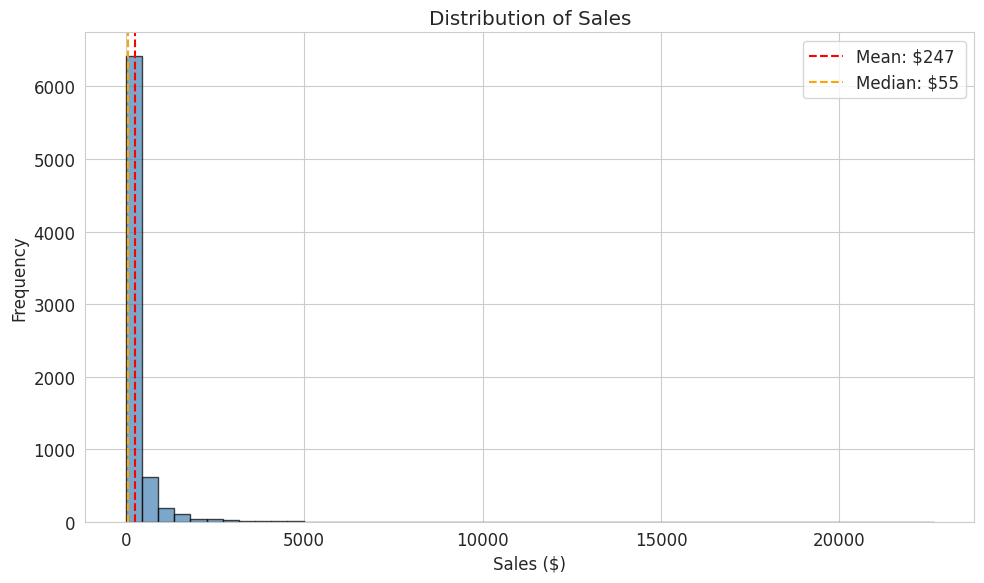

Interpretation: The distribution is right-skewed -- most orders are small,
with a long tail of high-value orders. Mean > Median confirms the skew.


In [62]:
# Find the sales column (may be 'Sales' or 'sales')
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[sales_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Sales')
ax.axvline(df[sales_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[sales_col].mean():,.0f}')
ax.axvline(df[sales_col].median(), color='orange', linestyle='--', label=f'Median: ${df[sales_col].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Interpretation: The distribution is right-skewed -- most orders are small,")
print(f"with a long tail of high-value orders. Mean > Median confirms the skew.")

---
## 2. Boxplot: Profit Distribution

A boxplot shows the quartiles (25th, 50th, 75th percentile) and outliers.

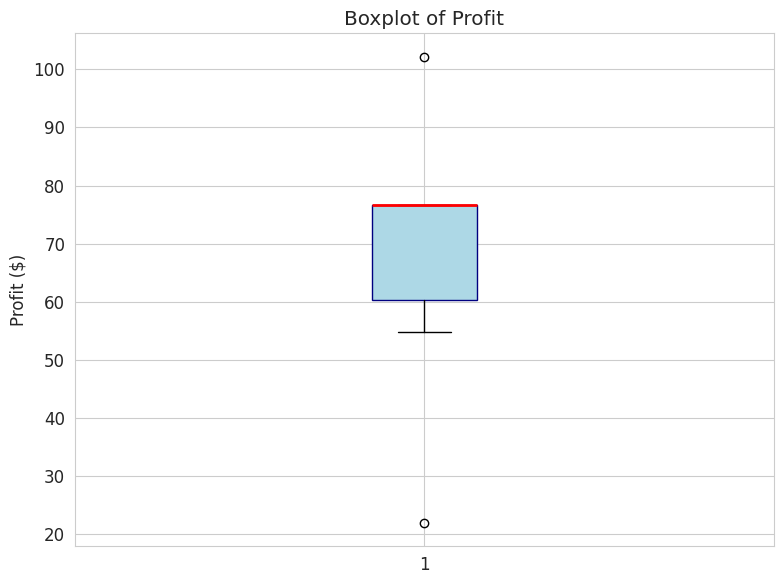

Q1: 60.22 | Q3: 76.64 | IQR: 16.42
Outlier boundaries: [35.58, 101.27]
Number of outliers: 2 (0.0% of data)


In [63]:
df.columns = df.columns.str.strip().str.replace(';', '')
# clean column names

profit_col = [c for c in df.columns if 'profit' in c.lower()][0]
# dynamically find Profit column

df[profit_col] = pd.to_numeric(df[profit_col], errors='coerce')
# convert to numeric

fig, ax = plt.subplots(figsize=(8, 6))
# create figure

bp = ax.boxplot(df[profit_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
# draw boxplot with styling

ax.set_ylabel('Profit ($)')
# label Y axis

ax.set_title('Boxplot of Profit')
# title

plt.tight_layout()
# adjust layout

plt.show()
# show plot


# ---- IQR OUTLIERS ----

Q1 = df[profit_col].quantile(0.25)
# 25th percentile

Q3 = df[profit_col].quantile(0.75)
# 75th percentile

IQR = Q3 - Q1
# interquartile range

lower_bound = Q1 - 1.5 * IQR
# lower threshold

upper_bound = Q3 + 1.5 * IQR
# upper threshold

n_outliers = ((df[profit_col] < lower_bound) | (df[profit_col] > upper_bound)).sum()
# count outliers

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Outlier boundaries: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
print(f"Number of outliers: {n_outliers} ({n_outliers/len(df):.1%} of data)")

---
## 3. Bar Chart: Sales by Category

Compare total sales across product categories.

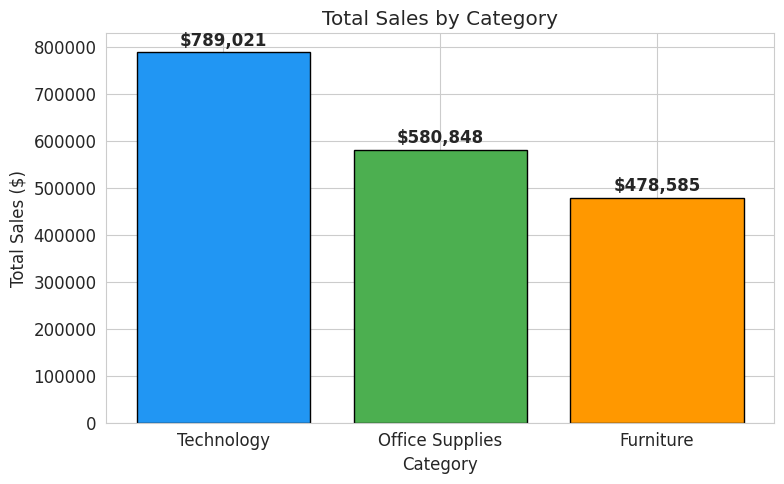

In [64]:
category_col = [c for c in df.columns if 'category' in c.lower()]
# Use the first match (usually 'Category', not 'Sub-Category')
cat_col = category_col[0] if category_col else None

if cat_col:
    cat_sales = df.groupby(cat_col)[sales_col].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cat_sales.index, cat_sales.values, color=['#2196F3', '#4CAF50', '#FF9800'],
                  edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, cat_sales.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Category')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Total Sales by Category')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Category' column found. Check column names above.")

---
## 4. Correlation Heatmap

Shows how numerical features relate to each other. Values range from -1 (perfect negative) to +1 (perfect positive).

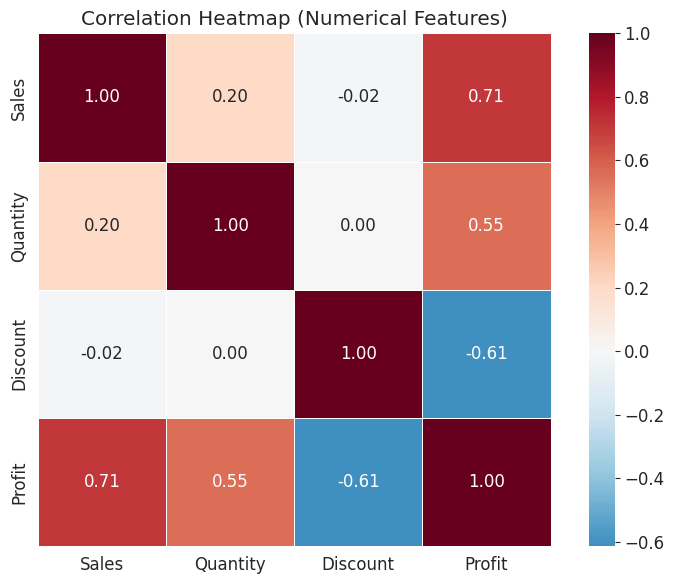

Interpretation:
- Look for strong positive correlations (close to +1): features that move together.
- Look for strong negative correlations (close to -1): features that move opposite.
- Remember: correlation does not imply causation.


In [65]:
# Select numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# Drop ID-like columns (Row ID, Postal Code, etc.) that are not meaningful for correlation
id_like = [c for c in num_df.columns if any(kw in c.lower() for kw in ['id', 'postal', 'code', 'zip'])]
num_df = num_df.drop(columns=id_like, errors='ignore')

corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Look for strong positive correlations (close to +1): features that move together.")
print("- Look for strong negative correlations (close to -1): features that move opposite.")
print("- Remember: correlation does not imply causation.")

---
## 5. Time Series: Monthly Sales Trend

Track how total sales change over time. Look for seasonality and trends.

/tmp/ipykernel_1637/1843035289.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()


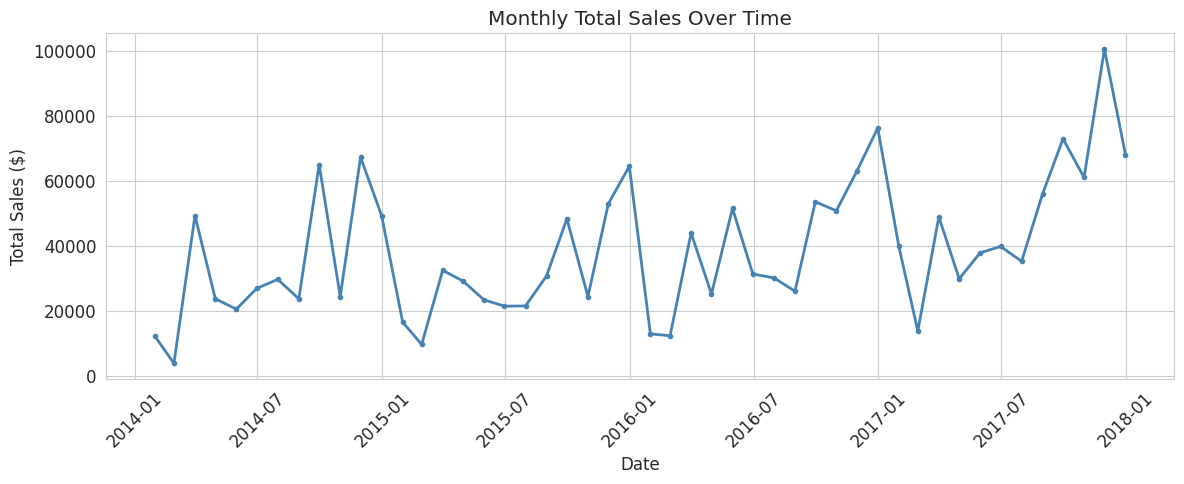

Look for:
- Overall trend (going up, down, or flat?)
- Seasonal patterns (spikes at certain times of year?)
- Anomalies (sudden drops or spikes?)


In [66]:
# Find the order date column
order_date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]

if order_date_col:
    odate = order_date_col[0]

    # Resample to monthly totals
    monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_sales.index, monthly_sales.values, color='steelblue',
            linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Monthly Total Sales Over Time')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    print("Look for:")
    print("- Overall trend (going up, down, or flat?)")
    print("- Seasonal patterns (spikes at certain times of year?)")
    print("- Anomalies (sudden drops or spikes?)")
else:
    print("No order date column found. Check column names.")

---
## Homework from pdf file



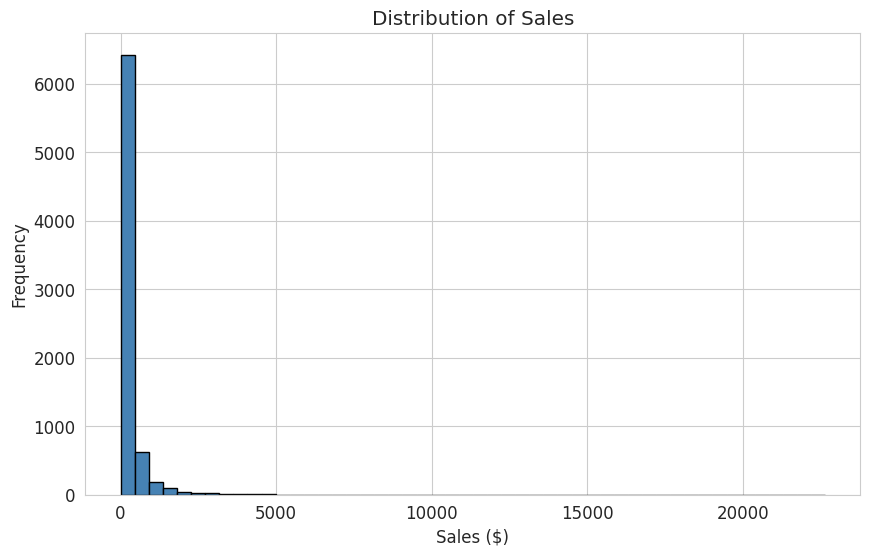

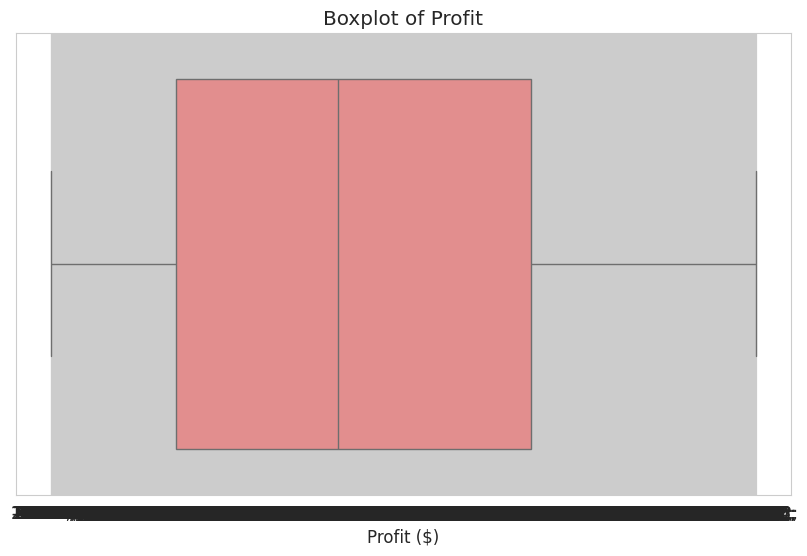

In [67]:
import pandas as pd  # library for working with data tables
import matplotlib.pyplot as plt  # library for plotting graphs
import seaborn as sns  # library for statistical visualizations

df = pd.read_csv('Sample - Superstore.csv')  # load CSV file into DataFrame
df['Order Date'] = pd.to_datetime(df['Order Date'])  # convert column to datetime format

plt.figure(figsize=(10, 6))  # create figure with specified size
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')  # plot histogram of Sales distribution
plt.title('Distribution of Sales')  # set plot title
plt.xlabel('Sales ($)')  # label for X-axis
plt.ylabel('Frequency')  # label for Y-axis
plt.show()  # display the histogram

plt.figure(figsize=(10, 6))  # create another figure
df.columns = df.columns.str.strip().str.replace(';', '')  # clean column names (remove spaces and ;)
sns.boxplot(x=df['Profit'], color='lightcoral')  # plot boxplot to show Profit distribution and outliers
plt.title('Boxplot of Profit')  # set plot title
plt.xlabel('Profit ($)')  # label for X-axis
plt.show()  # display the boxplot

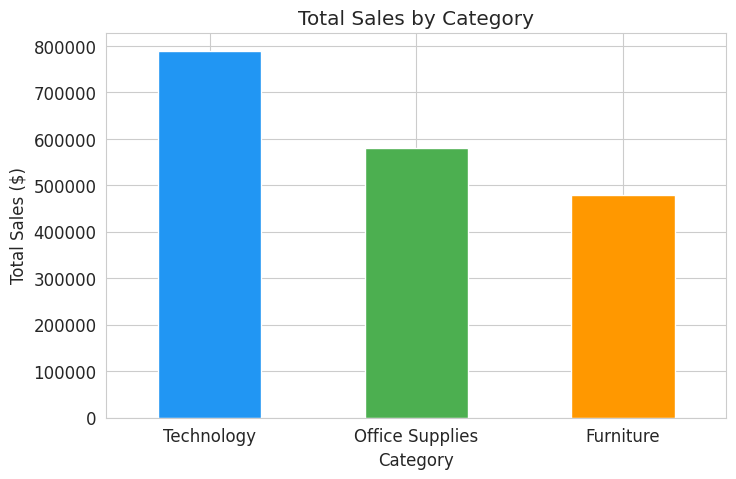

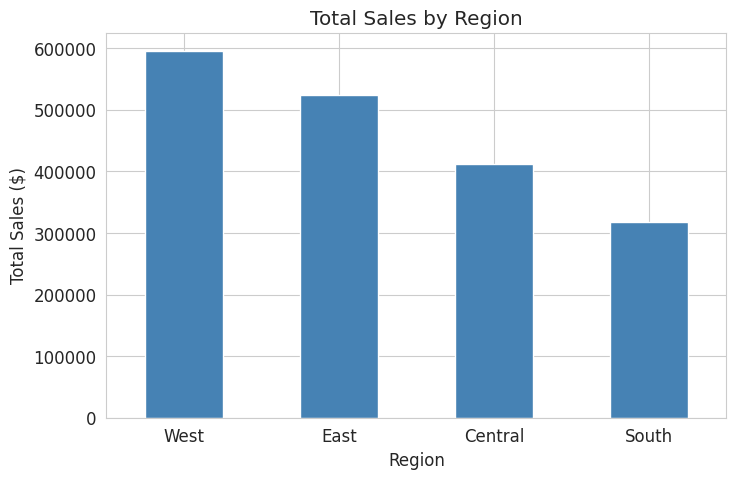

In [68]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
# group data by Category, sum Sales, and sort in descending order

plt.figure(figsize=(8, 5))  # create figure with size 8x5
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
# plot bar chart for total sales by category
plt.title('Total Sales by Category')  # set plot title
plt.xlabel('Category')  # label for X-axis
plt.ylabel('Total Sales ($)')  # label for Y-axis
plt.xticks(rotation=0)  # keep category labels horizontal
plt.show()  # display the chart

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
# group data by Region, sum Sales, and sort in descending order

plt.figure(figsize=(8, 5))  # create another figure
region_sales.plot(kind='bar', color='steelblue')
# plot bar chart for total sales by region
plt.title('Total Sales by Region')  # set plot title
plt.xlabel('Region')  # label for X-axis
plt.ylabel('Total Sales ($)')  # label for Y-axis
plt.xticks(rotation=0)  # keep region labels horizontal
plt.show()  # display the chart

In [69]:
df.columns = df.columns.str.strip().str.replace(';', '')
# clean column names

df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
# convert Profit to numeric values

Q1 = df['Profit'].quantile(0.25)
# 25th percentile

Q3 = df['Profit'].quantile(0.75)
# 75th percentile

IQR = Q3 - Q1
# interquartile range

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

lower_bound = Q1 - 1.5 * IQR
# lower outlier threshold

upper_bound = Q3 + 1.5 * IQR
# upper outlier threshold

print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
# filter outliers

print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.2f}%)")

Q1: 60.22, Q3: 76.64, IQR: 16.42
Lower bound: 35.58, Upper bound: 101.27
Number of outliers: 2 out of 9994 rows (0.02%)


             Sales  Quantity  Discount    Profit
Sales     1.000000  0.201741 -0.020294  0.707107
Quantity  0.201741  1.000000  0.004509  0.554700
Discount -0.020294  0.004509  1.000000 -0.613941
Profit    0.707107  0.554700 -0.613941  1.000000


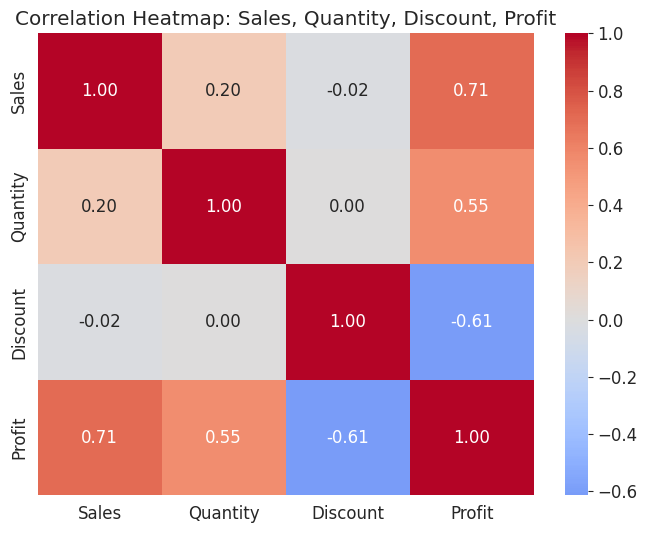

In [70]:
# select numerical columns for correlation analysis
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]

# compute correlation matrix (relationship between variables)
corr_matrix = numerical_cols.corr()

print(corr_matrix)  # display correlation values


plt.figure(figsize=(8, 6))  # create figure for heatmap

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# draw heatmap with:
# annot=True -> show numbers
# cmap='coolwarm' -> color scheme
# center=0 -> center colors around zero correlation

plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
# set title

plt.show()  # display heatmap

/tmp/ipykernel_1637/1524642613.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


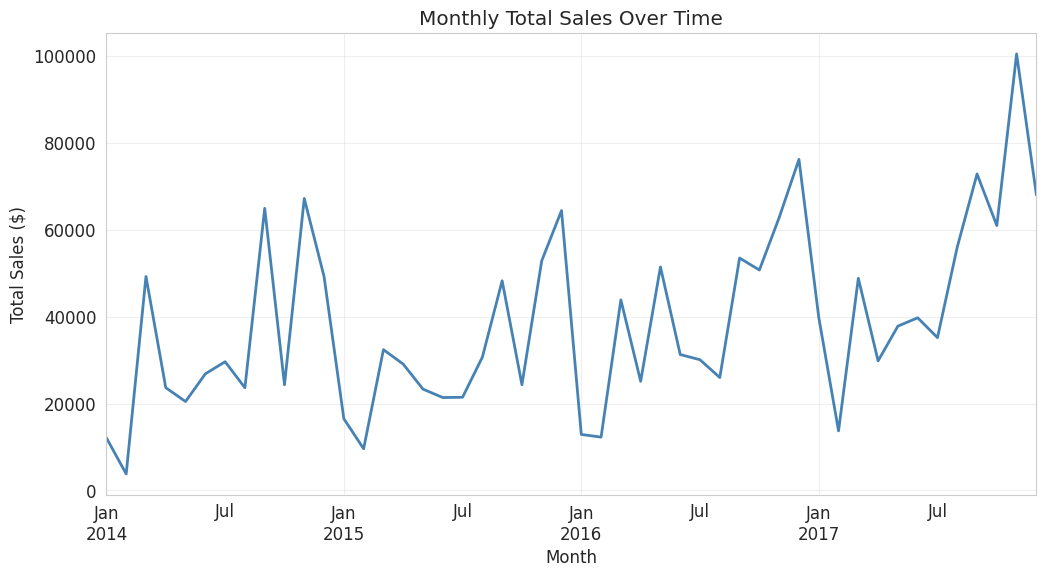

In [71]:
# resample data by month and calculate total sales per month
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))  # create figure with larger size

monthly_sales.plot(color='steelblue', linewidth=2)
# plot line chart of monthly sales over time

plt.title('Monthly Total Sales Over Time')  # set chart title
plt.xlabel('Month')  # label for X-axis (time)
plt.ylabel('Total Sales ($)')  # label for Y-axis (sales)

plt.grid(True, alpha=0.3)  # add light grid for readability

plt.show()  # display the plot